# Sampling (Reverse Diffusion)

Generation runs the reverse chain: start from $x_T \sim \mathcal{N}(0, \mathbf{I})$ and denoise step by step down to $x_0$.

## Reverse Posterior Derivation

We want $q(x_{t-1} \mid x_t, x_0)$. By Bayes:

$$q(x_{t-1} \mid x_t, x_0) \propto q(x_t \mid x_{t-1})\, q(x_{t-1} \mid x_0)$$

The denominator $q(x_t \mid x_0)$ has no $x_{t-1}$ in it — constant, folds into normalization.

Each term is a Gaussian over $\mathbb{R}^{C \times H \times W}$ (image treated as a flat vector); the squared terms are $\|\cdot\|^2$, summed over all components. We only need the exponents:

$$q(x_t \mid x_{t-1}) \propto \exp\!\left(-\frac{\|x_t - \sqrt{\alpha_t}\,x_{t-1}\|^2}{2\beta_t}\right)$$

$$q(x_{t-1} \mid x_0) \propto \exp\!\left(-\frac{\|x_{t-1} - \sqrt{\bar{\alpha}_{t-1}}\,x_0\|^2}{2(1-\bar{\alpha}_{t-1})}\right)$$

Add the exponents and collect by powers of $x_{t-1}$:

$$\propto -\frac{1}{2}\left[\left(\frac{\alpha_t}{\beta_t} + \frac{1}{1-\bar{\alpha}_{t-1}}\right)\|x_{t-1}\|^2 - 2\left(\frac{\sqrt{\alpha_t}}{\beta_t}x_t + \frac{\sqrt{\bar{\alpha}_{t-1}}}{1-\bar{\alpha}_{t-1}}x_0\right)\cdot x_{t-1}\right]$$

This is a quadratic in $x_{t-1}$, so it's a Gaussian. Match to $-\frac{1}{2\tilde{\beta}_t}\|x_{t-1} - \tilde{\mu}_t\|^2$:

**Variance:**

$$\frac{1}{\tilde{\beta}_t} = \frac{\alpha_t}{\beta_t} + \frac{1}{1-\bar{\alpha}_{t-1}} = \frac{1-\bar{\alpha}_t}{\beta_t(1-\bar{\alpha}_{t-1})} \quad\Rightarrow\quad \boxed{\tilde{\beta}_t = \frac{\beta_t\,(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}}$$

**Mean:**

$$\frac{\tilde{\mu}_t}{\tilde{\beta}_t} = \frac{\sqrt{\alpha_t}}{\beta_t}x_t + \frac{\sqrt{\bar{\alpha}_{t-1}}}{1-\bar{\alpha}_{t-1}}x_0 \quad\Rightarrow\quad \boxed{\tilde{\mu}_t = \frac{\sqrt{\bar{\alpha}_{t-1}}\,\beta_t}{1-\bar{\alpha}_t}\,x_0 + \frac{\sqrt{\alpha_t}\,(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}\,x_t}$$

At generation time, substitute $\hat{x}_0 = \frac{x_t - \sqrt{1-\bar{\alpha}_t}\,\varepsilon_\theta}{\sqrt{\bar{\alpha}_t}}$ since $x_0$ is unknown.

**Sample** via reparametrization: $x_{t-1} = \tilde{\mu}_t + \sqrt{\tilde{\beta}_t}\,\varepsilon,\quad \varepsilon \sim \mathcal{N}(0,\mathbf{I})$

*(At $t=1$, $\tilde{\beta}_t \to 0$ so we skip the noise term and return $\tilde{\mu}_t$ directly.)*

In [10]:
import torch
import matplotlib.pyplot as plt
import math

%run 02_unet.ipynb

input:  torch.Size([4, 1, 28, 28])
output: torch.Size([4, 1, 28, 28])


## Noise Schedule

In [11]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

T          = 1000
betas      = torch.linspace(1e-4, 0.02, T).to(device)   # index 0..T-1 = t=1..T
alphas     = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)                # index 0..T-1 = ᾱ_1..ᾱ_T

## Sampling Loop

In [12]:
@torch.no_grad()
def sample(model, labels, image_size=(1, 28, 28)):
    model.eval()
    
    n = labels.shape[0]    
    C, H, W = image_size
    xt = torch.randn(n, C, H, W, device=device)  # x_T ~ N(0, I)

    for t in reversed(range(T)):  # t = T-1 down to 0, representing timesteps T down to 1
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)

        ab      = alpha_bars[t]                                           # ᾱ_t
        ab_prev = alpha_bars[t - 1] if t > 0 else torch.tensor(1.0, device=device)  # ᾱ_{t-1}
        beta    = betas[t]
        alpha   = alphas[t]

        eps_pred = model(xt, t_batch, labels)
        x0_hat   = (xt - (1 - ab).sqrt() * eps_pred) / ab.sqrt()
        x0_hat   = x0_hat.clamp(-1, 1)

        mu  = (ab_prev.sqrt() * beta / (1 - ab)) * x0_hat \
            + (alpha.sqrt() * (1 - ab_prev) / (1 - ab)) * xt
        var = beta * (1 - ab_prev) / (1 - ab)

        noise = torch.randn_like(xt) if t > 0 else torch.zeros_like(xt)
        xt    = mu + var.sqrt() * noise

    return xt  # x_0

## Generate

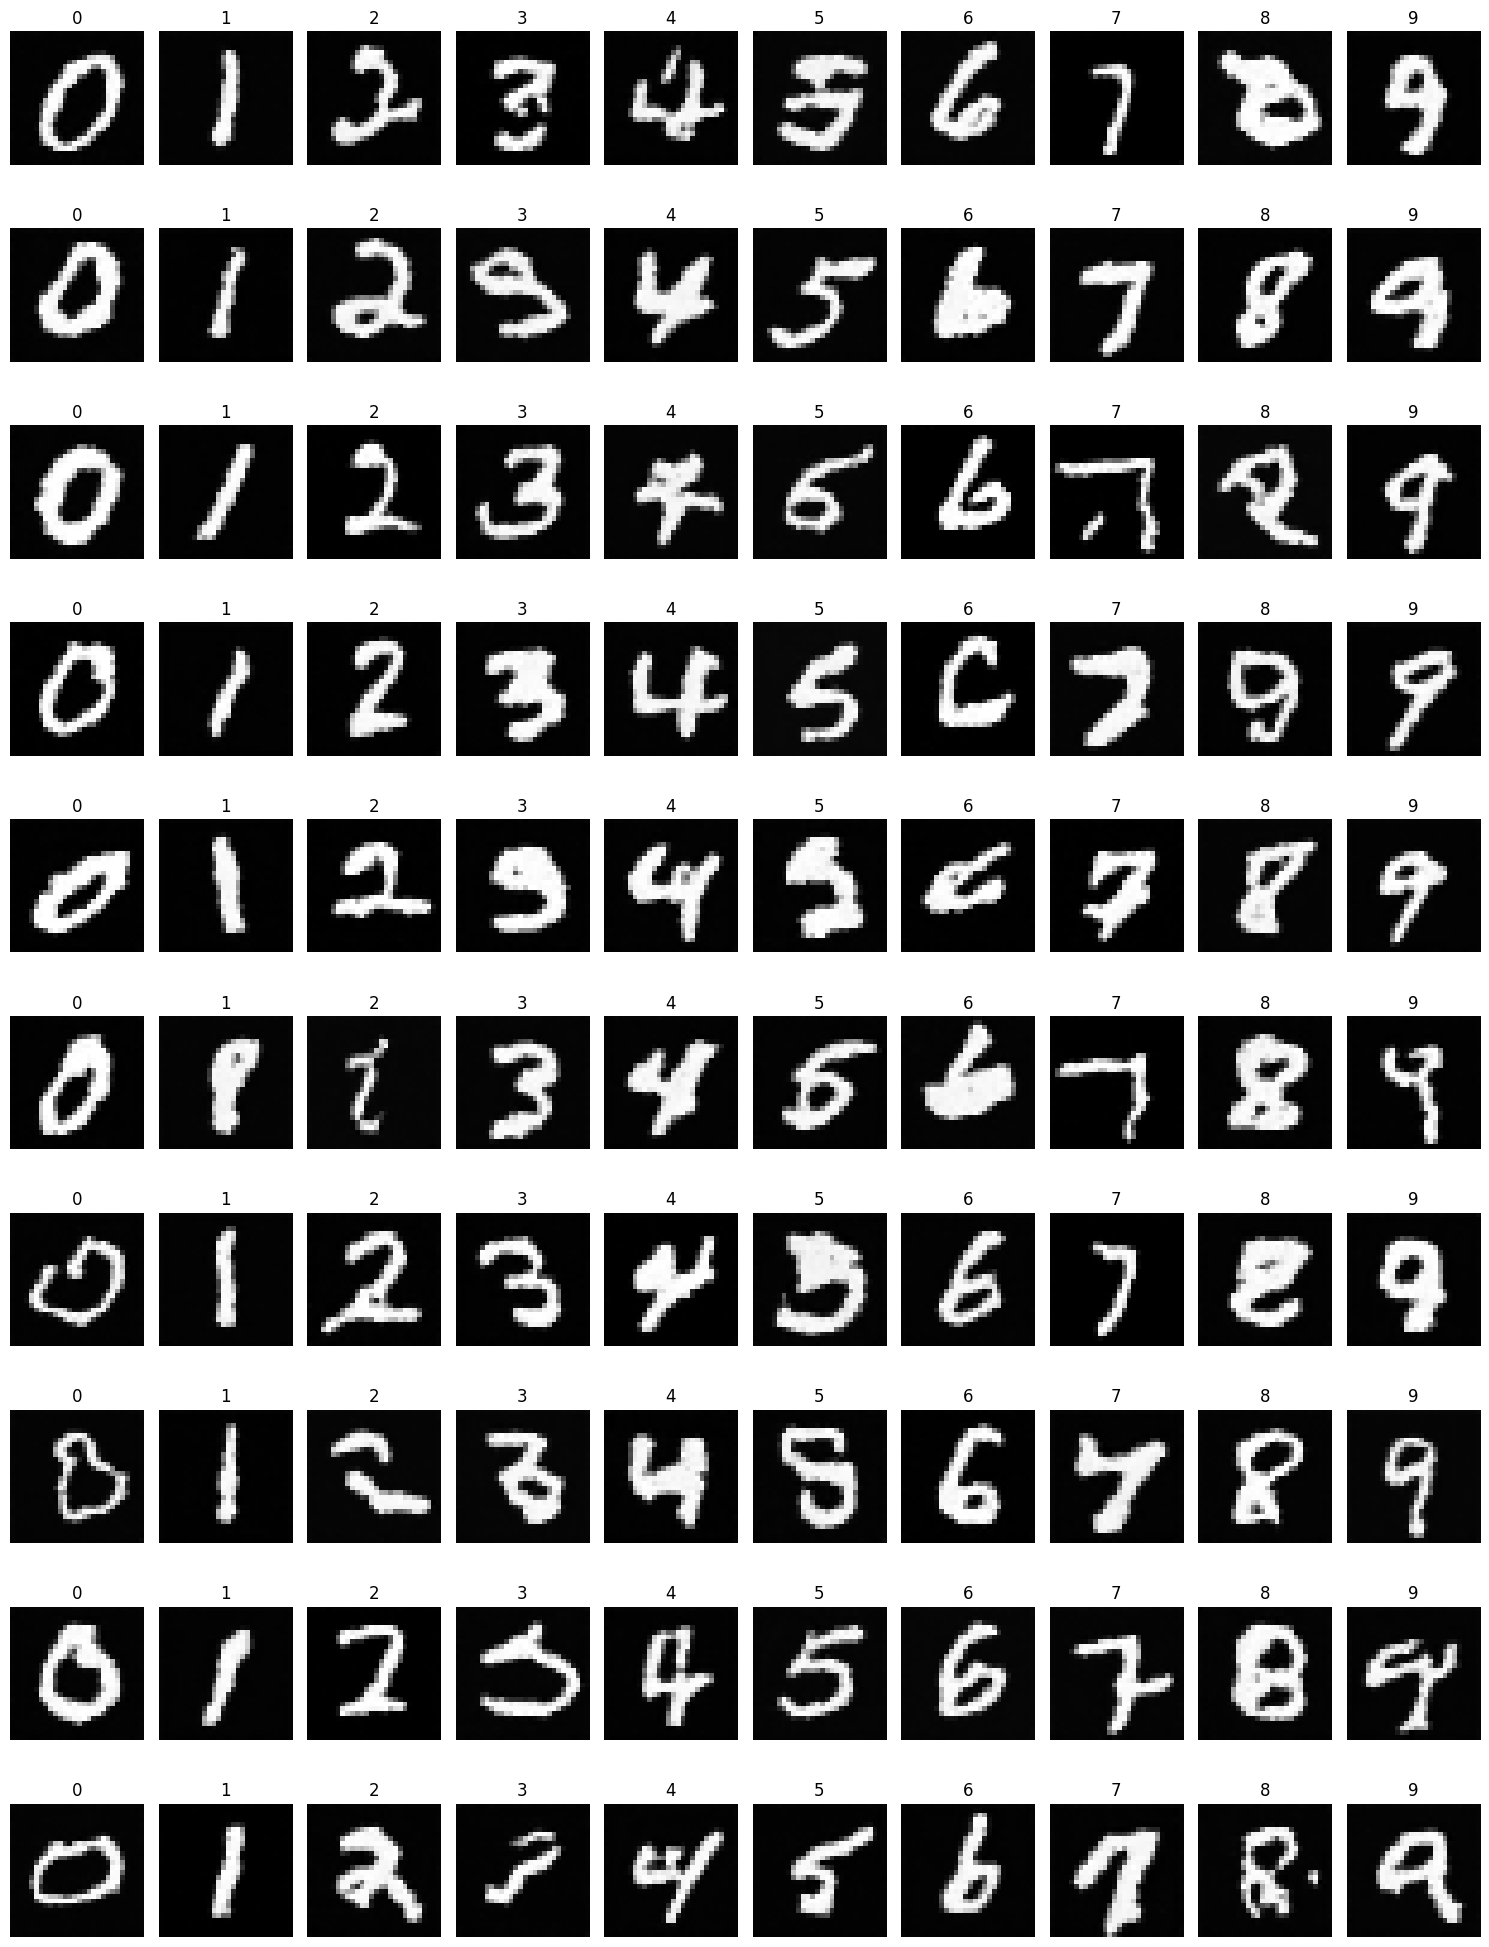

In [16]:
model = UNet().to(device)
model.load_state_dict(torch.load('../data/unet_mnist.pt', map_location=device))

m = 10
labels = torch.arange(10, device=device).repeat(m)

samples = sample(model, labels=labels)
samples = (samples + 1) / 2  # [-1,1] -> [0,1]

fig, axes = plt.subplots(m, 10, figsize=(15, 20))
for ax, img, label in zip(axes.flat, samples, labels):
    ax.imshow(img.cpu().squeeze(), cmap='gray')
    ax.set_title(str(label.item()))
    ax.axis('off')
plt.tight_layout()
plt.show()